In [1]:
import torch
import torchvision
import numpy as np
import torch.nn as nn
import seaborn as sns
import torch.optim as optim
import matplotlib.pyplot as plt
from collections import Counter
import torchvision.models as models
import torchvision.datasets as datasets
import torchvision.transforms as transforms
from sklearn.metrics import confusion_matrix
from torch.utils.data import DataLoader, random_split

In [2]:
from sklearn.model_selection import StratifiedShuffleSplit
from torch.utils.data import DataLoader, Subset
# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Dataset path
dataset_path = "/kaggle/input/odir-5k-org-multi-class-5-gcahm-class-full-dataset/multi_class_5_GCAHM_Class_full_dataset copy"

# Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# # Enhanced data augmentation and normalization
# train_transform = transforms.Compose([
#     transforms.Resize((256, 256)),
#     transforms.RandomResizedCrop(224, scale=(0.7, 1.0)),  # More aggressive cropping
#     transforms.RandomHorizontalFlip(),
#     transforms.RandomVerticalFlip(),
#     transforms.RandomRotation(20),  # Increased rotation
#     transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
#     transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),  # Random translation
#     transforms.RandomGrayscale(p=0.1),  # Occasional grayscale
#     transforms.ToTensor(),
#     transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
#     transforms.RandomErasing(p=0.2, scale=(0.02, 0.2), ratio=(0.3, 3.3))  # Random erasing
# ])

# # Validation and test transforms (no augmentation)
# val_transform = transforms.Compose([
#     transforms.Resize((256, 256)),
#     transforms.CenterCrop(224),
#     transforms.ToTensor(),
#     transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
# ])

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),  # Slightly larger for EfficientNet
    transforms.RandomResizedCrop(256, scale=(0.7, 1.0)),  # More aggressive cropping
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),  # Increased rotation
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),  # Random translation
    transforms.RandomGrayscale(p=0.1),  # Occasional grayscale
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    transforms.RandomErasing(p=0.2, scale=(0.02, 0.2), ratio=(0.3, 3.3))  # Random erasing
])

# Train transforms (no augmentation)
# train_transform = transforms.Compose([
#     transforms.Resize((224, 224)),
#     transforms.CenterCrop(256),
#     transforms.ToTensor(),
#     transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
# ])
# Validation and test transforms (no augmentation)
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.CenterCrop(256),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# # Load dataset and create splits
# full_dataset = datasets.ImageFolder(root=dataset_path)

# # Create stratified splits to maintain class distribution

# # First split: 85% train+val, 15% test
# sss = StratifiedShuffleSplit(n_splits=1, test_size=0.15, random_state=42)
# train_val_idx, test_idx = next(sss.split(np.zeros(len(full_dataset)), full_dataset.targets))

# train_val_dataset = torch.utils.data.Subset(full_dataset, train_val_idx)
# test_dataset = torch.utils.data.Subset(full_dataset, test_idx)

# # Second split: 85% train, 15% val from train_val
# sss = StratifiedShuffleSplit(n_splits=1, test_size=0.15, random_state=42)
# train_idx, val_idx = next(sss.split(np.zeros(len(train_val_dataset)), [full_dataset.targets[i] for i in train_val_idx]))

# train_dataset = torch.utils.data.Subset(full_dataset, [train_val_idx[i] for i in train_idx])
# val_dataset = torch.utils.data.Subset(full_dataset, [train_val_idx[i] for i in val_idx])

# # Apply transforms
# train_dataset.dataset.transform = train_transform
# val_dataset.dataset.transform = val_transform
# test_dataset.dataset.transform = val_transform

# # DataLoaders
# batch_size = 32
# train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, 
#                          num_workers=4, pin_memory=True, drop_last=True)  # Drop last to avoid small batches
# val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=4)
# test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=4)



# Load the full dataset
full_dataset = datasets.ImageFolder(root=dataset_path)

# Get targets for stratified splitting
targets = full_dataset.targets
n_total = len(targets)

# First split: 15% test, 85% train_val
sss1 = StratifiedShuffleSplit(n_splits=1, test_size=0.15, random_state=42)
train_val_idx, test_idx = next(sss1.split(np.zeros(n_total), targets))

# Second split: from 85% train_val, split 70% train and 15% val
# 70% out of total = ~82.35% of train_val; 15% out of total = ~17.65% of train_val
relative_val_size = 15 / (70 + 15)  # == 0.1765

train_val_targets = [targets[i] for i in train_val_idx]
sss2 = StratifiedShuffleSplit(n_splits=1, test_size=relative_val_size, random_state=42)
train_idx, val_idx = next(sss2.split(np.zeros(len(train_val_targets)), train_val_targets))

# Get actual indices
train_dataset = Subset(full_dataset, [train_val_idx[i] for i in train_idx])
val_dataset = Subset(full_dataset, [train_val_idx[i] for i in val_idx])
test_dataset = Subset(full_dataset, test_idx)

# Assign transforms
train_dataset.dataset.transform = train_transform
val_dataset.dataset.transform = val_transform
test_dataset.dataset.transform = val_transform

# DataLoaders
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,
                          num_workers=4, pin_memory=True, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=4)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=4)


Using device: cuda


In [3]:
# # Compute Class Distribution for Train-Validation Only
# num_classes = len(full_dataset.classes)
# labels = [full_dataset.targets[idx] for idx in train_val_dataset.indices]

# label_counts = Counter(labels)
# total_samples = sum(label_counts.values())

# # Compute Class Weights
# class_weights = [total_samples / (num_classes * label_counts[i]) for i in range(num_classes)]
# class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)

# class_names = full_dataset.classes
# print(class_weights)


from collections import Counter

# Combine train and val indices
combined_indices = train_dataset.indices + val_dataset.indices
combined_labels = [full_dataset.targets[idx] for idx in combined_indices]

# Compute class distribution
label_counts = Counter(combined_labels)
total_samples = sum(label_counts.values())
num_classes = len(full_dataset.classes)

# Compute class weights
class_weights = [total_samples / (num_classes * label_counts[i]) for i in range(num_classes)]
class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)

# For reference
class_names = full_dataset.classes
print("Class Weights:", class_weights)


Class Weights: tensor([0.9044, 0.8209, 0.8481, 1.8752, 1.0376], device='cuda:0')


In [4]:
# DenseNet-121 Model
model = torchvision.models.densenet121(pretrained=True)

# Freeze all layers except classifier
for param in model.parameters():
    param.requires_grad = False

# Unfreeze last dense block (partial fine-tuning)
for param in model.features.denseblock4.parameters():
    param.requires_grad = True

# Modify classifier
in_features = model.classifier.in_features
model.classifier = nn.Sequential(
    nn.Linear(in_features, 512),
    nn.BatchNorm1d(512),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(512, num_classes)
)
model = model.to(device)

# # CBAM Attention Modules
# class ChannelAttention(nn.Module):
#     def __init__(self, in_planes, ratio=16):
#         super(ChannelAttention, self).__init__()
#         self.avg_pool = nn.AdaptiveAvgPool2d(1)
#         self.max_pool = nn.AdaptiveMaxPool2d(1)
        
#         self.fc = nn.Sequential(
#             nn.Conv2d(in_planes, in_planes // ratio, 1, bias=False),
#             nn.ReLU(),
#             nn.Conv2d(in_planes // ratio, in_planes, 1, bias=False)
#         )
#         self.sigmoid = nn.Sigmoid()

#     def forward(self, x):
#         avg_out = self.fc(self.avg_pool(x))
#         max_out = self.fc(self.max_pool(x))
#         out = avg_out + max_out
#         return self.sigmoid(out)

# class SpatialAttention(nn.Module):
#     def __init__(self, kernel_size=7):
#         super(SpatialAttention, self).__init__()
#         self.conv = nn.Conv2d(2, 1, kernel_size, padding=kernel_size//2, bias=False)
#         self.sigmoid = nn.Sigmoid()

#     def forward(self, x):
#         avg_out = torch.mean(x, dim=1, keepdim=True)
#         max_out, _ = torch.max(x, dim=1, keepdim=True)
#         x = torch.cat([avg_out, max_out], dim=1)
#         x = self.conv(x)
#         return self.sigmoid(x)

# class CBAM(nn.Module):
#     def __init__(self, channels, reduction=16, kernel_size=7):
#         super(CBAM, self).__init__()
#         self.ca = ChannelAttention(channels, reduction)
#         self.sa = SpatialAttention(kernel_size)

#     def forward(self, x):
#         x = x * self.ca(x)
#         x = x * self.sa(x)
#         return x

# # Modified DenseNet with CBAM
# class DenseNet121_CBAM(nn.Module):
#     def __init__(self, num_classes=8):
#         super(DenseNet121_CBAM, self).__init__()
#         # Load pretrained DenseNet121
#         self.base_model = models.densenet121(pretrained=True)
        
#         # Freeze all layers except classifier
#         for param in self.base_model.parameters():
#             param.requires_grad = False
            
#         # Unfreeze last dense block (partial fine-tuning)
#         for param in self.base_model.features.denseblock4.parameters():
#             param.requires_grad = True
            
#         # Add CBAM modules after each dense block
#         self.base_model.features.transition1 = nn.Sequential(
#             self.base_model.features.transition1,
#             CBAM(self.base_model.features.transition1.conv.out_channels)
#         )
#         self.base_model.features.transition2 = nn.Sequential(
#             self.base_model.features.transition2,
#             CBAM(self.base_model.features.transition2.conv.out_channels)
#         )
#         self.base_model.features.transition3 = nn.Sequential(
#             self.base_model.features.transition3,
#             CBAM(self.base_model.features.transition3.conv.out_channels)
#         )
        
#         # Add CBAM after the last dense block
#         self.base_model.features.norm5 = nn.Sequential(
#             self.base_model.features.norm5,
#             CBAM(self.base_model.features.norm5.num_features)
#         )
        
#         # Modify classifier
#         in_features = self.base_model.classifier.in_features
#         self.base_model.classifier = nn.Sequential(
#             nn.Linear(in_features, 512),
#             nn.BatchNorm1d(512),
#             nn.ReLU(),
#             nn.Dropout(0.5),
#             nn.Linear(512, num_classes)
#         )
        
#     def forward(self, x):
#         return self.base_model(x)


# model = DenseNet121_CBAM(num_classes=num_classes).to(device)

epochs = 35 
# Loss with label smoothing and class weights
criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)

# Optimizer with weight decay
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-3)  # AdamW is better with weight decay

# Learning rate scheduler
# scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=2, verbose=True)
scheduler = optim.lr_scheduler.OneCycleLR(optimizer, max_lr=1e-3,
                                        steps_per_epoch=len(train_loader),
                                        epochs=epochs)


# Early stopping
early_stopping_patience = 5
best_val_accuracy = 0
epochs_without_improvement = 0

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DenseNet121_Weights.IMAGENET1K_V1`. You can also use `weights=DenseNet121_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth
100%|██████████| 30.8M/30.8M [00:00<00:00, 96.0MB/s]


Epoch 1/35:
Train Loss: 1.4636, Acc: 41.11%
Val Loss: 1.2376, Acc: 59.12%
New best model saved with val acc: 59.12%
Epoch 2/35:
Train Loss: 1.0702, Acc: 65.02%
Val Loss: 1.0279, Acc: 67.96%
New best model saved with val acc: 67.96%
Epoch 3/35:
Train Loss: 0.9294, Acc: 74.76%
Val Loss: 0.9502, Acc: 73.48%
New best model saved with val acc: 73.48%
Epoch 4/35:
Train Loss: 0.8262, Acc: 80.77%
Val Loss: 0.9046, Acc: 75.69%
New best model saved with val acc: 75.69%
Epoch 5/35:
Train Loss: 0.7659, Acc: 85.46%
Val Loss: 0.8712, Acc: 76.24%
New best model saved with val acc: 76.24%
Epoch 6/35:
Train Loss: 0.6931, Acc: 87.98%
Val Loss: 0.8606, Acc: 76.80%
New best model saved with val acc: 76.80%
Epoch 7/35:
Train Loss: 0.6501, Acc: 91.83%
Val Loss: 0.8414, Acc: 79.56%
New best model saved with val acc: 79.56%
Epoch 8/35:
Train Loss: 0.6111, Acc: 93.27%
Val Loss: 0.8276, Acc: 82.32%
New best model saved with val acc: 82.32%
Epoch 9/35:
Train Loss: 0.5866, Acc: 95.07%
Val Loss: 0.8144, Acc: 82.32

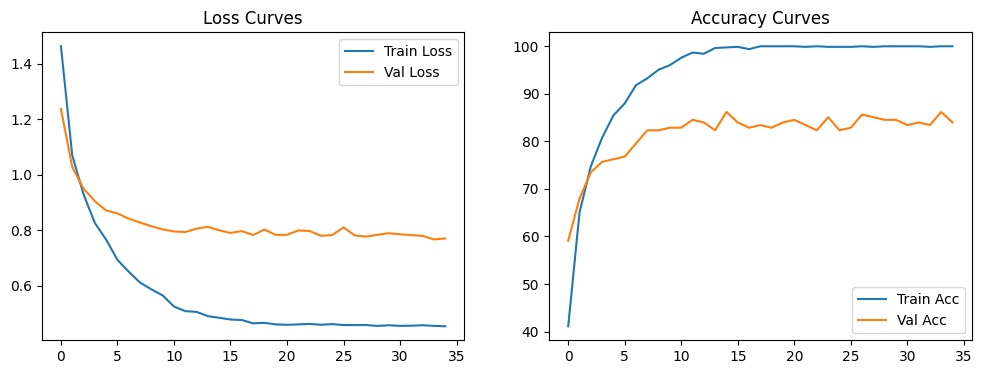

In [5]:
best_val_accuracy = 0
train_losses, val_losses = [], []
train_accs, val_accs = [], []

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    
    train_loss = running_loss / len(train_loader)
    train_acc = 100 * correct / total
    train_losses.append(train_loss)
    train_accs.append(train_acc)
    
    scheduler.step()
    # Validation
    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0
    
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()
    
    val_loss /= len(val_loader)
    val_acc = 100 * val_correct / val_total
    val_losses.append(val_loss)
    val_accs.append(val_acc)
    
    # scheduler.step(val_acc)
    
    print(f'Epoch {epoch+1}/{epochs}:')
    print(f'Train Loss: {train_loss:.4f}, Acc: {train_acc:.2f}%')
    print(f'Val Loss: {val_loss:.4f}, Acc: {val_acc:.2f}%')
    
    if val_acc > best_val_accuracy:
        best_val_accuracy = val_acc
        torch.save(model.state_dict(), 'best_effnetb7_cbam.pth')
        print(f'New best model saved with val acc: {val_acc:.2f}%')

# Plotting and evaluation (same as before)
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.legend()
plt.title('Loss Curves')

plt.subplot(1, 2, 2)
plt.plot(train_accs, label='Train Acc')
plt.plot(val_accs, label='Val Acc')
plt.legend()
plt.title('Accuracy Curves')
plt.show()

# Evaluation on Final model


================= Evaluating Final Model (after Last Epoch) =================

Final Model Test Accuracy: 88.40%

Classification Report (Final Model):
              precision    recall  f1-score   support

           A       0.84      0.80      0.82        40
           C       1.00      0.95      0.98        44
           G       0.89      0.79      0.84        43
           H       0.65      0.89      0.76        19
           M       0.95      1.00      0.97        35

    accuracy                           0.88       181
   macro avg       0.87      0.89      0.87       181
weighted avg       0.89      0.88      0.89       181


Per-class Metrics (Final Model):
A               - Precision: 0.8421, Recall: 0.8000, F1: 0.8205 Accuracy: 80.00%
C               - Precision: 1.0000, Recall: 0.9545, F1: 0.9767 Accuracy: 95.45%
G               - Precision: 0.8947, Recall: 0.7907, F1: 0.8395 Accuracy: 79.07%
H               - Precision: 0.6538, Recall: 0.8947, F1: 0.7556 Accuracy: 89.47%
M

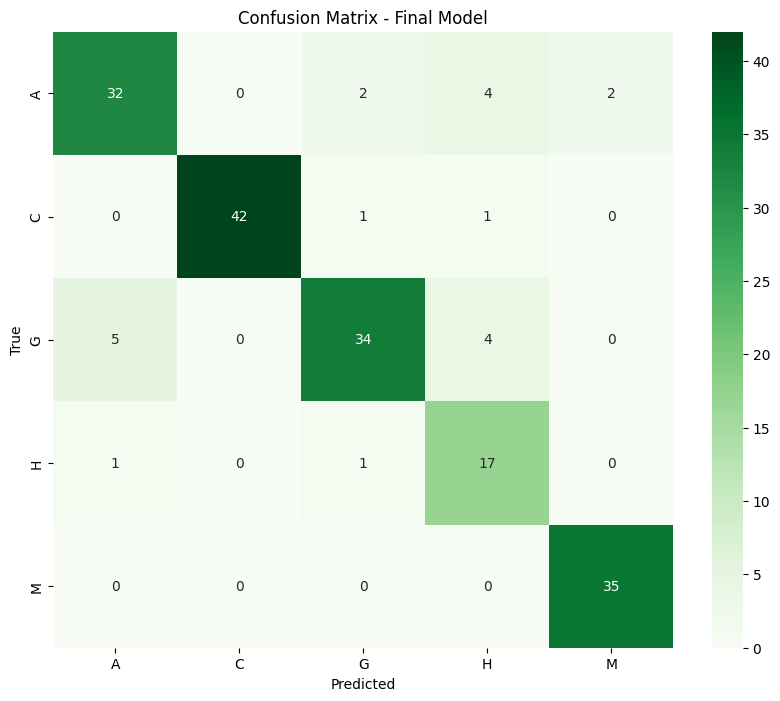

In [6]:
from sklearn.metrics import classification_report, precision_recall_fscore_support
print("\n================= Evaluating Final Model (after Last Epoch) =================")
# model.load_state_dict(torch.load('best_effnetb7_cbam.pth'))  # Remove this line to use final model
# model is already in its final state from training loop

model.eval()
y_true = []
y_pred = []
test_correct = 0
test_total = 0

# Per-class correct counts and totals for accuracy calculation
class_correct = [0] * len(test_dataset.dataset.classes)
class_total = [0] * len(test_dataset.dataset.classes)

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, predicted = torch.max(outputs.data, 1)
        test_total += labels.size(0)
        test_correct += (predicted == labels).sum().item()

        # Track per-class correct predictions and total samples
        for i in range(labels.size(0)):
            label = labels[i]
            class_total[label] += 1
            if predicted[i] == label:
                class_correct[label] += 1
        
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(predicted.cpu().numpy())

test_acc = 100 * test_correct / test_total
print(f'\nFinal Model Test Accuracy: {test_acc:.2f}%')

class_names = test_dataset.dataset.classes
print("\nClassification Report (Final Model):")
print(classification_report(y_true, y_pred, target_names=class_names))

precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average=None)
print("\nPer-class Metrics (Final Model):")
for i, class_name in enumerate(test_dataset.dataset.classes):
    per_class_acc = 100 * class_correct[i] / class_total[i] if class_total[i] > 0 else 0
    print(f"{class_name:15s} - Precision: {precision[i]:.4f}, Recall: {recall[i]:.4f}, F1: {f1[i]:.4f} Accuracy: {per_class_acc:.2f}%")

overall_precision, overall_recall, overall_f1, _ = precision_recall_fscore_support(
    y_true, y_pred, average='macro'
)
print(f"\nOverall Metrics (Final Model, Macro-average):")
print(f"Precision: {overall_precision:.4f}")
print(f"Recall: {overall_recall:.4f}")
print(f"F1 Score: {overall_f1:.4f}")

conf_matrix = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Greens',
            xticklabels=class_names, 
            yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix - Final Model')
plt.show()


Val Accuracy: 83.98%

Classification Report(on validaition):
              precision    recall  f1-score   support

           A       0.86      0.78      0.82        40
           C       0.84      0.98      0.91        44
           G       0.89      0.72      0.79        43
           H       0.61      0.74      0.67        19
           M       0.92      0.94      0.93        35

    accuracy                           0.84       181
   macro avg       0.82      0.83      0.82       181
weighted avg       0.85      0.84      0.84       181


Per-class Metrics:
A               - Precision: 0.8611, Recall: 0.7750, F1: 0.8158 Accuracy: 77.50%
C               - Precision: 0.8431, Recall: 0.9773, F1: 0.9053 Accuracy: 97.73%
G               - Precision: 0.8857, Recall: 0.7209, F1: 0.7949 Accuracy: 72.09%
H               - Precision: 0.6087, Recall: 0.7368, F1: 0.6667 Accuracy: 73.68%
M               - Precision: 0.9167, Recall: 0.9429, F1: 0.9296 Accuracy: 94.29%

Overall Metrics (Macro-

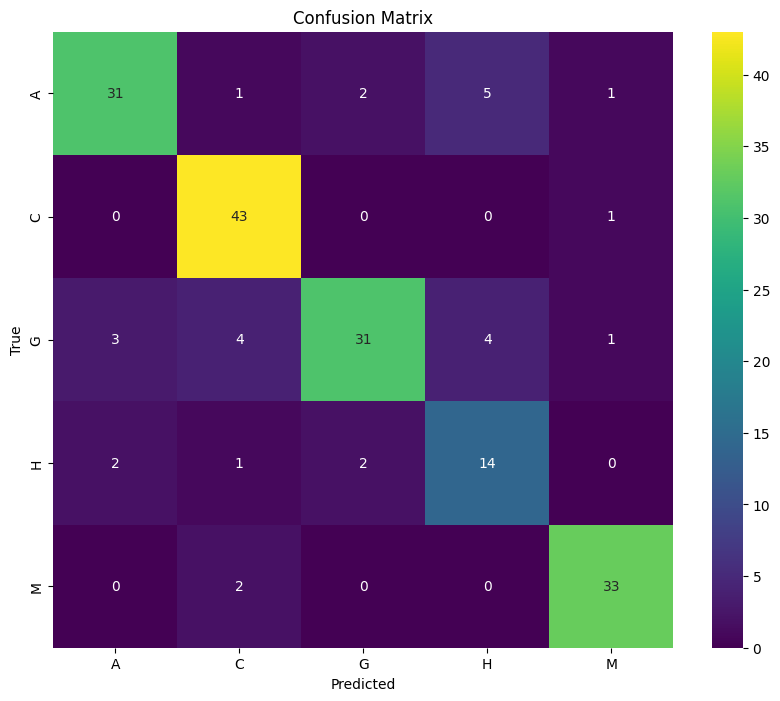

In [7]:
# Val evaluation
test_correct = 0
test_total = 0
y_true = []
y_pred = []

# Per-class correct counts and totals for accuracy calculation
class_correct = [0] * len(test_dataset.dataset.classes)
class_total = [0] * len(test_dataset.dataset.classes)

with torch.no_grad():
    model.eval()  # Set model to evaluation mode
    for inputs, labels in val_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, predicted = torch.max(outputs.data, 1)
        test_total += labels.size(0)
        test_correct += (predicted == labels).sum().item()

        # Track per-class correct predictions and total samples
        for i in range(labels.size(0)):
            label = labels[i]
            class_total[label] += 1
            if predicted[i] == label:
                class_correct[label] += 1
        
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(predicted.cpu().numpy())

test_acc = 100 * test_correct / test_total
print(f'\nVal Accuracy: {test_acc:.2f}%')

# Detailed classification report
print("\nClassification Report(on validaition):")
print(classification_report(y_true, y_pred, target_names=val_dataset.dataset.classes))

# Per-class metrics
precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average=None)
print("\nPer-class Metrics:")
for i, class_name in enumerate(val_dataset.dataset.classes):
    per_class_acc = 100 * class_correct[i] / class_total[i] if class_total[i] > 0 else 0
    print(f"{class_name:15s} - Precision: {precision[i]:.4f}, Recall: {recall[i]:.4f}, F1: {f1[i]:.4f} Accuracy: {per_class_acc:.2f}%")

# Overall metrics (macro-average)
overall_precision, overall_recall, overall_f1, _ = precision_recall_fscore_support(
    y_true, y_pred, average='macro'
)
print(f"\nOverall Metrics (Macro-average):")
print(f"Precision: {overall_precision:.4f}")
print(f"Recall: {overall_recall:.4f}")
print(f"F1 Score: {overall_f1:.4f}")

# Confusion matrix
conf_matrix = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='viridis',
            xticklabels=test_dataset.dataset.classes, 
            yticklabels=test_dataset.dataset.classes)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()



Showing sample test images with actual and predicted labels:


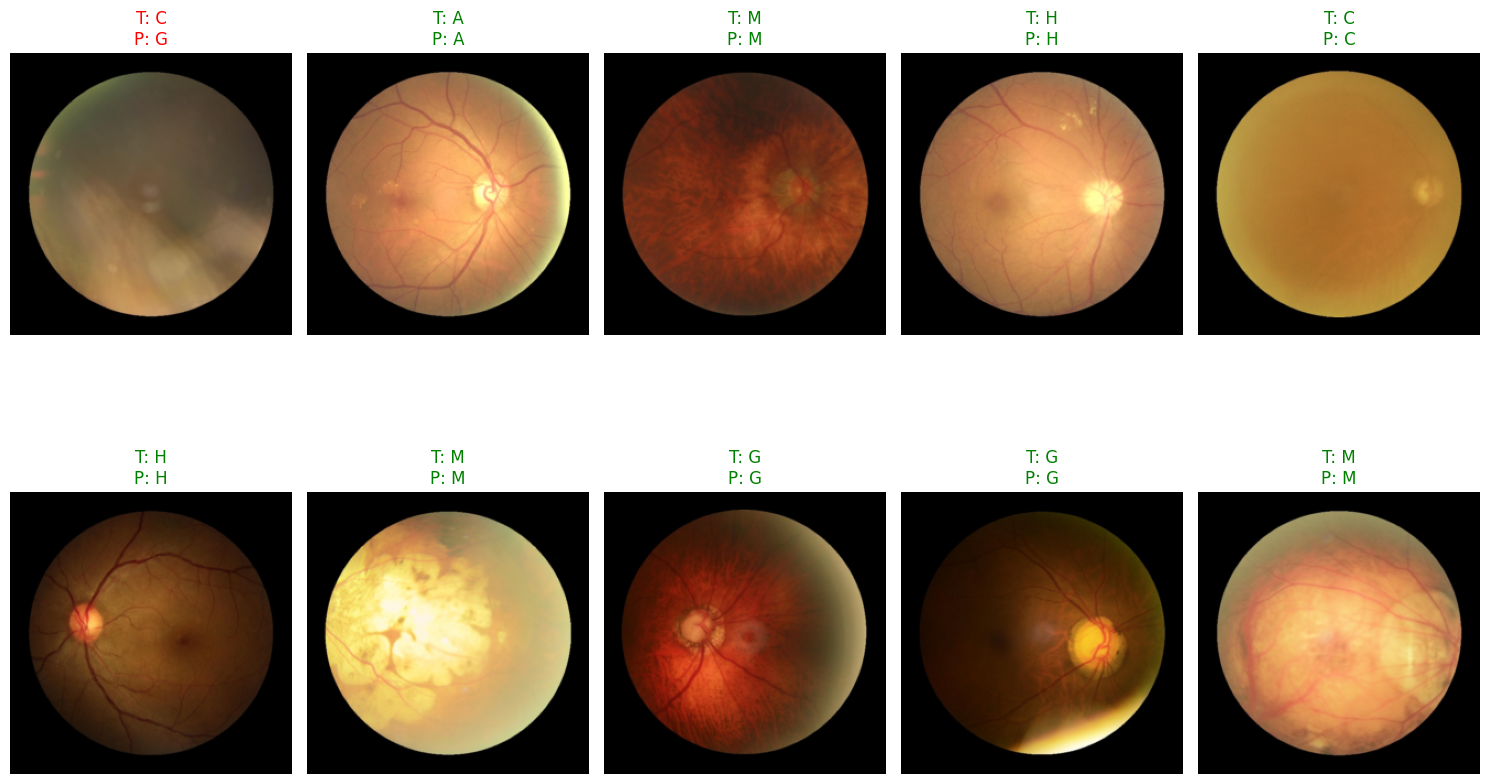

In [8]:
import matplotlib.pyplot as plt
import torch
import numpy as np
import torchvision

# Function to show a batch of images with predicted vs true labels
def show_predictions(images, true_labels, pred_labels, class_names, num_images=6):
    images = images.cpu()
    
    # Adjust the number of rows and columns
    num_rows = 2  # Number of rows
    num_columns = num_images // num_rows  # Number of images per row

    fig, axs = plt.subplots(num_rows, num_columns, figsize=(15, 10))  # Adjust the figure size
    axs = axs.flatten()  # Flatten the axis array for easy indexing

    for i in range(num_images):
        img = images[i].permute(1, 2, 0).numpy()
        img = img * [0.229, 0.224, 0.225] + [0.485, 0.456, 0.406]  # De-normalize
        img = np.clip(img, 0, 1)
        
        axs[i].imshow(img)
        axs[i].axis('off')
        axs[i].set_title(f"T: {class_names[true_labels[i]]}\nP: {class_names[pred_labels[i]]}",
                         color="green" if true_labels[i] == pred_labels[i] else "red")
    
    plt.tight_layout()
    plt.show()

# Show a few images from the test set
print("\nShowing sample test images with actual and predicted labels:")

# Iterate one batch (or more, as needed)
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, predicted = torch.max(outputs.data, 1)
        
        show_predictions(inputs, labels, predicted, class_names, num_images=10)
        break  # Remove this break if you want to display multiple batches


# Evaluation on Best Model


================= Evaluating Best Model =================

Test Accuracy: 88.95%

Classification Report:
              precision    recall  f1-score   support

           A       0.85      0.72      0.78        40
           C       1.00      0.93      0.96        44
           G       0.87      0.91      0.89        43
           H       0.74      0.89      0.81        19
           M       0.92      1.00      0.96        35

    accuracy                           0.89       181
   macro avg       0.88      0.89      0.88       181
weighted avg       0.89      0.89      0.89       181


Per-class Metrics:
A               - Precision: 0.8529, Recall: 0.7250, F1: 0.7838 Accuracy: 72.50%
C               - Precision: 1.0000, Recall: 0.9318, F1: 0.9647 Accuracy: 93.18%
G               - Precision: 0.8667, Recall: 0.9070, F1: 0.8864 Accuracy: 90.70%
H               - Precision: 0.7391, Recall: 0.8947, F1: 0.8095 Accuracy: 89.47%
M               - Precision: 0.9211, Recall: 1.0000, F1: 0.95

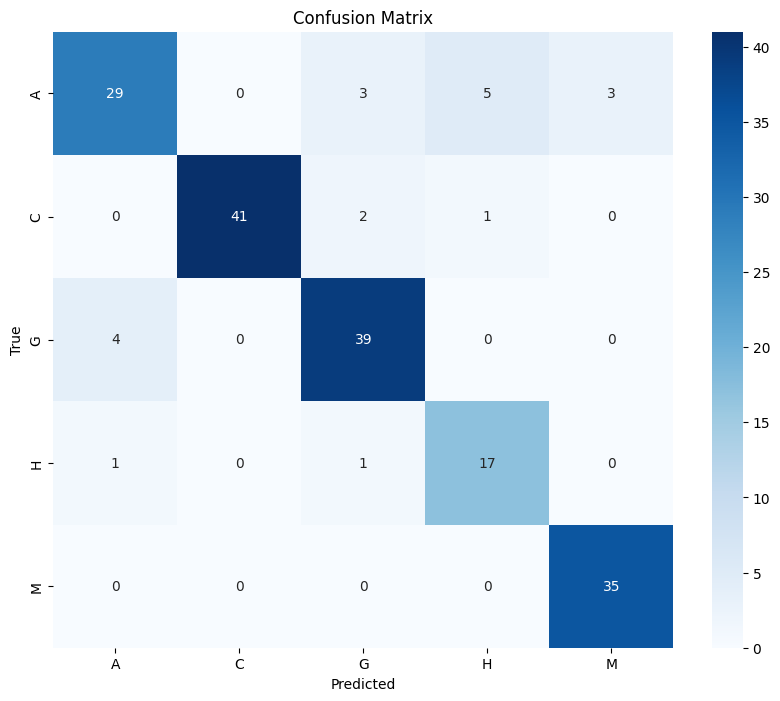

In [9]:
print("\n================= Evaluating Best Model =================")
from sklearn.metrics import classification_report, precision_recall_fscore_support
# Load best model and evaluate
model.load_state_dict(torch.load('best_effnetb7_cbam.pth'))
model.eval()
# Test evaluation
test_correct = 0
test_total = 0
y_true = []
y_pred = []

# Per-class correct counts and totals for accuracy calculation
class_correct = [0] * len(test_dataset.dataset.classes)
class_total = [0] * len(test_dataset.dataset.classes)

with torch.no_grad():
    model.eval()  # Set model to evaluation mode
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, predicted = torch.max(outputs.data, 1)
        test_total += labels.size(0)
        test_correct += (predicted == labels).sum().item()

        # Track per-class correct predictions and total samples
        for i in range(labels.size(0)):
            label = labels[i]
            class_total[label] += 1
            if predicted[i] == label:
                class_correct[label] += 1

        
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(predicted.cpu().numpy())
        
test_acc = 100 * test_correct / test_total
print(f'\nTest Accuracy: {test_acc:.2f}%')

# Detailed classification report
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=test_dataset.dataset.classes))

# Per-class metrics
precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average=None)
print("\nPer-class Metrics:")
for i, class_name in enumerate(test_dataset.dataset.classes):
    per_class_acc = 100 * class_correct[i] / class_total[i] if class_total[i] > 0 else 0
    print(f"{class_name:15s} - Precision: {precision[i]:.4f}, Recall: {recall[i]:.4f}, F1: {f1[i]:.4f} Accuracy: {per_class_acc:.2f}%")

    # Per-class accuracy
    # print(f"{class_name:15s} - ")


# Overall metrics (macro-average)
overall_precision, overall_recall, overall_f1, _ = precision_recall_fscore_support(
    y_true, y_pred, average='macro'
)
print(f"\nOverall Metrics (Macro-average):")
print(f"Precision: {overall_precision:.4f}")
print(f"Recall: {overall_recall:.4f}")
print(f"F1 Score: {overall_f1:.4f}")

# Confusion matrix
conf_matrix = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=test_dataset.dataset.classes, 
            yticklabels=test_dataset.dataset.classes)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()


Val Accuracy: 86.19%

Classification Report(on validaition):
              precision    recall  f1-score   support

           A       0.90      0.68      0.77        40
           C       0.90      0.98      0.93        44
           G       0.81      0.91      0.86        43
           H       0.74      0.74      0.74        19
           M       0.92      0.94      0.93        35

    accuracy                           0.86       181
   macro avg       0.85      0.85      0.85       181
weighted avg       0.86      0.86      0.86       181


Per-class Metrics:
A               - Precision: 0.9000, Recall: 0.6750, F1: 0.7714 Accuracy: 67.50%
C               - Precision: 0.8958, Recall: 0.9773, F1: 0.9348 Accuracy: 97.73%
G               - Precision: 0.8125, Recall: 0.9070, F1: 0.8571 Accuracy: 90.70%
H               - Precision: 0.7368, Recall: 0.7368, F1: 0.7368 Accuracy: 73.68%
M               - Precision: 0.9167, Recall: 0.9429, F1: 0.9296 Accuracy: 94.29%

Overall Metrics (Macro-

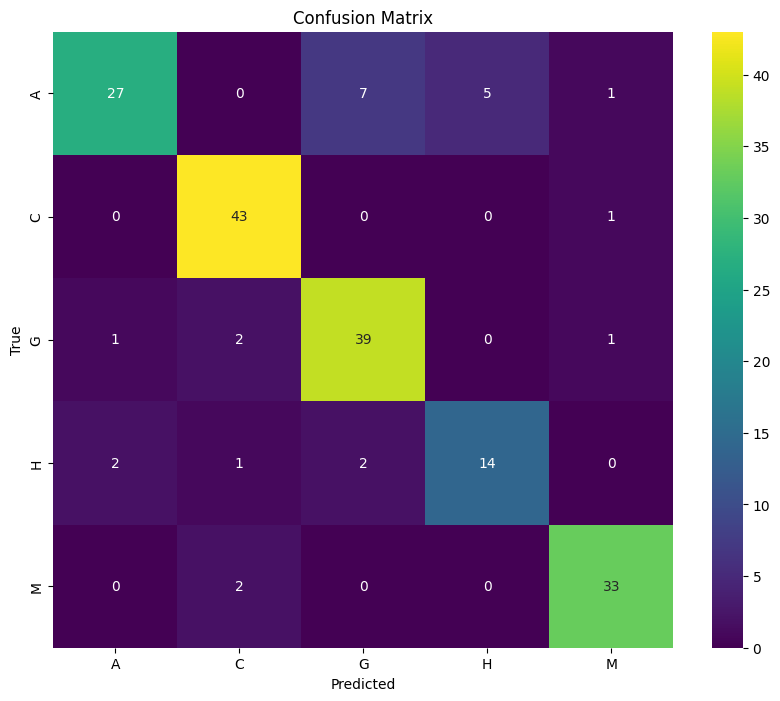

In [10]:
# Val evaluation
test_correct = 0
test_total = 0
y_true = []
y_pred = []
model.load_state_dict(torch.load('best_effnetb7_cbam.pth'))
model.eval()
# Per-class correct counts and totals for accuracy calculation
class_correct = [0] * len(test_dataset.dataset.classes)
class_total = [0] * len(test_dataset.dataset.classes)

with torch.no_grad():
    model.eval()  # Set model to evaluation mode
    for inputs, labels in val_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, predicted = torch.max(outputs.data, 1)
        test_total += labels.size(0)
        test_correct += (predicted == labels).sum().item()

        # Track per-class correct predictions and total samples
        for i in range(labels.size(0)):
            label = labels[i]
            class_total[label] += 1
            if predicted[i] == label:
                class_correct[label] += 1
        
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(predicted.cpu().numpy())

test_acc = 100 * test_correct / test_total
print(f'\nVal Accuracy: {test_acc:.2f}%')

# Detailed classification report
print("\nClassification Report(on validaition):")
print(classification_report(y_true, y_pred, target_names=val_dataset.dataset.classes))

# Per-class metrics
precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average=None)
print("\nPer-class Metrics:")
for i, class_name in enumerate(val_dataset.dataset.classes):
    per_class_acc = 100 * class_correct[i] / class_total[i] if class_total[i] > 0 else 0
    print(f"{class_name:15s} - Precision: {precision[i]:.4f}, Recall: {recall[i]:.4f}, F1: {f1[i]:.4f} Accuracy: {per_class_acc:.2f}%")

# Overall metrics (macro-average)
overall_precision, overall_recall, overall_f1, _ = precision_recall_fscore_support(
    y_true, y_pred, average='macro'
)
print(f"\nOverall Metrics (Macro-average):")
print(f"Precision: {overall_precision:.4f}")
print(f"Recall: {overall_recall:.4f}")
print(f"F1 Score: {overall_f1:.4f}")

# Confusion matrix
conf_matrix = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='viridis',
            xticklabels=test_dataset.dataset.classes, 
            yticklabels=test_dataset.dataset.classes)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()



Showing sample test images with actual and predicted labels:


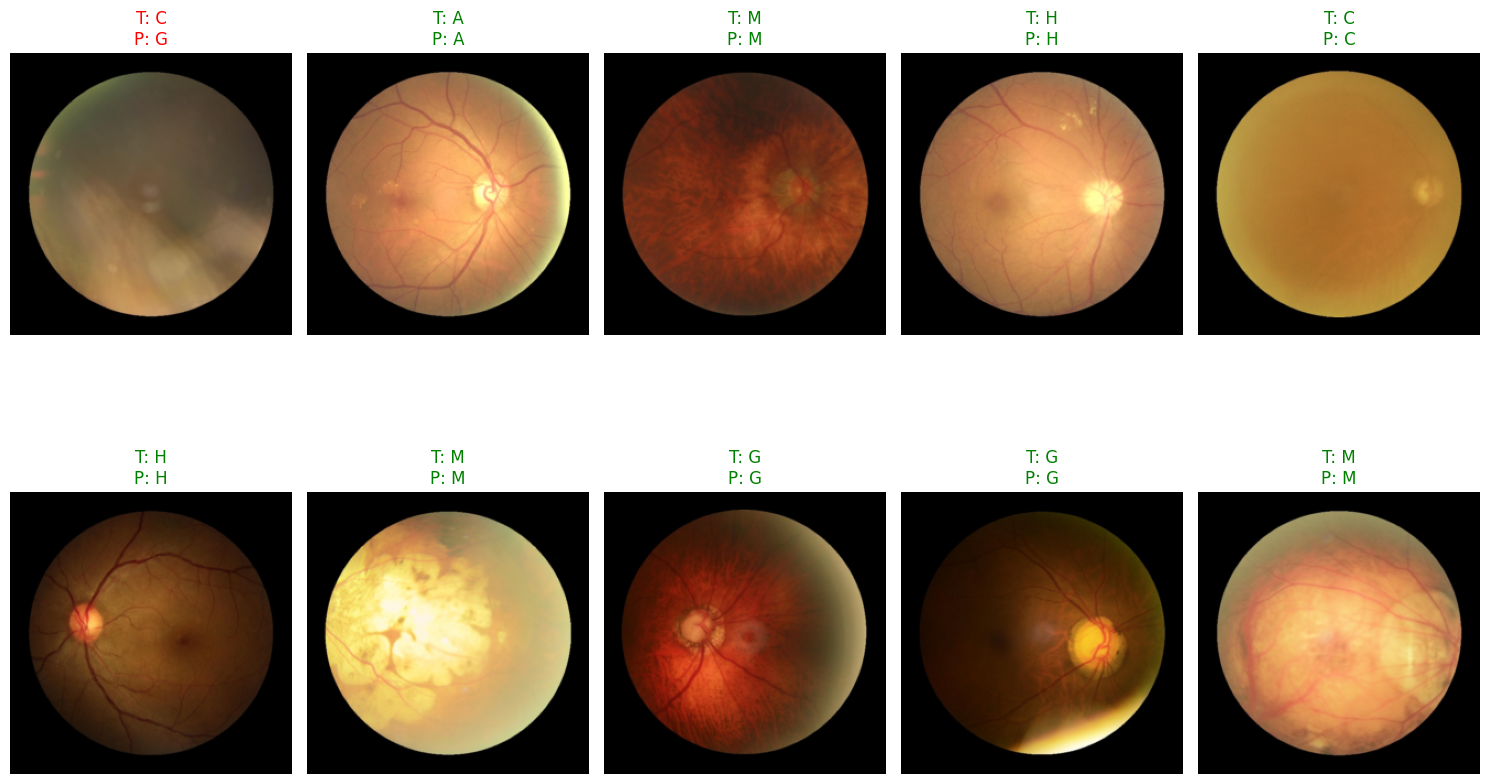

In [11]:
import matplotlib.pyplot as plt
import torch
import numpy as np
import torchvision
model.load_state_dict(torch.load('best_effnetb7_cbam.pth'))
# Function to show a batch of images with predicted vs true labels
def show_predictions(images, true_labels, pred_labels, class_names, num_images=6):
    images = images.cpu()
    
    # Adjust the number of rows and columns
    num_rows = 2  # Number of rows
    num_columns = num_images // num_rows  # Number of images per row

    fig, axs = plt.subplots(num_rows, num_columns, figsize=(15, 10))  # Adjust the figure size
    axs = axs.flatten()  # Flatten the axis array for easy indexing

    for i in range(num_images):
        img = images[i].permute(1, 2, 0).numpy()
        img = img * [0.229, 0.224, 0.225] + [0.485, 0.456, 0.406]  # De-normalize
        img = np.clip(img, 0, 1)
        
        axs[i].imshow(img)
        axs[i].axis('off')
        axs[i].set_title(f"T: {class_names[true_labels[i]]}\nP: {class_names[pred_labels[i]]}",
                         color="green" if true_labels[i] == pred_labels[i] else "red")
    
    plt.tight_layout()
    plt.show()

# Show a few images from the test set
print("\nShowing sample test images with actual and predicted labels:")

# Iterate one batch (or more, as needed)
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, predicted = torch.max(outputs.data, 1)
        
        show_predictions(inputs, labels, predicted, class_names, num_images=10)
        break  # Remove this break if you want to display multiple batches
